In [1]:
# ============================================================
# DAY 11 — CELL 1
# DRIVE MOUNT + LOCAL PROJECT RESTORE
# ============================================================

from google.colab import drive
from pathlib import Path
import shutil
import torch

# ------------------------------------------------------------
# 1. Mount Google Drive FIRST
# ------------------------------------------------------------

print("=" * 60)
print("GOOGLE DRIVE MOUNT")
print("=" * 60)

drive.mount("/content/drive", force_remount=False)

# ------------------------------------------------------------
# 2. Define project paths
# ------------------------------------------------------------

DRIVE_PROJECT = Path(
    "/content/drive/MyDrive/MediScan"
)

LOCAL_PROJECT = Path(
    "/content/MediScan"
)

DRIVE_DATA = DRIVE_PROJECT / "data"
DRIVE_RAW = DRIVE_DATA / "raw"
DRIVE_PROCESSED = DRIVE_DATA / "processed"

DRIVE_FIGURES = DRIVE_PROJECT / "figures"
DRIVE_REPORTS = DRIVE_PROJECT / "reports"
DRIVE_MODELS = DRIVE_PROJECT / "models"

LOCAL_DATA = LOCAL_PROJECT / "data"
LOCAL_RAW = LOCAL_DATA / "raw"
LOCAL_PROCESSED = LOCAL_DATA / "processed"

LOCAL_FIGURES = LOCAL_PROJECT / "figures"
LOCAL_REPORTS = LOCAL_PROJECT / "reports"
LOCAL_MODELS = LOCAL_PROJECT / "models"

# ------------------------------------------------------------
# 3. Create local directories
# ------------------------------------------------------------

for path in [
    LOCAL_RAW,
    LOCAL_PROCESSED,
    LOCAL_FIGURES,
    LOCAL_REPORTS,
    LOCAL_MODELS
]:
    path.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 4. Restore RAW dataset locally
# ------------------------------------------------------------

print()
print("=" * 60)
print("RAW DATA RESTORE")
print("=" * 60)

local_raw_count = (
    len(list(LOCAL_RAW.rglob("*")))
    if LOCAL_RAW.exists()
    else 0
)

print("Local raw files found :", local_raw_count)

if local_raw_count < 7000:

    print("Local raw dataset incomplete.")
    print("Restoring from Google Drive...")

    if LOCAL_RAW.exists():
        shutil.rmtree(LOCAL_RAW)

    shutil.copytree(
        DRIVE_RAW,
        LOCAL_RAW
    )

    print("✓ Raw dataset restored locally")

else:

    print("✓ Local raw dataset already available")

# ------------------------------------------------------------
# 5. Restore processed dataset
# ------------------------------------------------------------

print()
print("=" * 60)
print("PROCESSED DATA RESTORE")
print("=" * 60)

processed_files = [
    "train.csv",
    "val.csv",
    "test.csv",
    "class_to_idx.json"
]

for filename in processed_files:

    source = DRIVE_PROCESSED / filename
    destination = LOCAL_PROCESSED / filename

    if source.exists():

        shutil.copy2(
            source,
            destination
        )

        print(f"✓ {filename}")

# ------------------------------------------------------------
# 6. Restore previous model checkpoints
# ------------------------------------------------------------

print()
print("=" * 60)
print("PREVIOUS MODEL RESTORE")
print("=" * 60)

model_files = [
    "efficientnet_b0_best_day7.pth",
    "efficientnet_b0_best_day8.pth"
]

for filename in model_files:

    source = DRIVE_MODELS / filename
    destination = LOCAL_MODELS / filename

    if source.exists():

        shutil.copy2(
            source,
            destination
        )

        print(f"✓ {filename}")

    else:

        print(f"⚠ Missing: {filename}")

# ------------------------------------------------------------
# 7. Restore previous figures
# ------------------------------------------------------------

print()
print("=" * 60)
print("PREVIOUS FIGURES RESTORE")
print("=" * 60)

figure_count = 0

if DRIVE_FIGURES.exists():

    for source in DRIVE_FIGURES.iterdir():

        if source.is_file():

            destination = LOCAL_FIGURES / source.name

            shutil.copy2(
                source,
                destination
            )

            figure_count += 1

print("Figures restored:", figure_count)

# ------------------------------------------------------------
# 8. Restore previous reports
# ------------------------------------------------------------

print()
print("=" * 60)
print("PREVIOUS REPORTS RESTORE")
print("=" * 60)

report_count = 0

if DRIVE_REPORTS.exists():

    for source in DRIVE_REPORTS.iterdir():

        if source.is_file():

            destination = LOCAL_REPORTS / source.name

            shutil.copy2(
                source,
                destination
            )

            report_count += 1

print("Reports restored:", report_count)

# ------------------------------------------------------------
# 9. Verify important files
# ------------------------------------------------------------

print()
print("=" * 60)
print("DAY 11 LOCAL PROJECT VERIFICATION")
print("=" * 60)

verification = {
    "Local raw dataset" :
        LOCAL_RAW.exists(),

    "train.csv" :
        (LOCAL_PROCESSED / "train.csv").exists(),

    "val.csv" :
        (LOCAL_PROCESSED / "val.csv").exists(),

    "test.csv" :
        (LOCAL_PROCESSED / "test.csv").exists(),

    "class_to_idx.json" :
        (LOCAL_PROCESSED / "class_to_idx.json").exists(),

    "Day 7 model" :
        (LOCAL_MODELS /
         "efficientnet_b0_best_day7.pth").exists(),

    "Day 8 model" :
        (LOCAL_MODELS /
         "efficientnet_b0_best_day8.pth").exists(),
}

for item, status in verification.items():
    print(f"{item:25s}: {status}")

# ------------------------------------------------------------
# 10. GPU verification
# ------------------------------------------------------------

print()
print("=" * 60)
print("PYTORCH / GPU VERIFICATION")
print("=" * 60)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Device          :", device)

if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )

print()
print("=" * 60)
print("✓ DAY 11 ENVIRONMENT READY")
print("=" * 60)

print("Drive mounted successfully")
print("Previous project files restored locally")
print("Local raw dataset ready for fast loading")
print("Previous EfficientNet models available")
print("Ready for ResNet50 setup")

GOOGLE DRIVE MOUNT
Mounted at /content/drive

RAW DATA RESTORE
Local raw files found : 0
Local raw dataset incomplete.
Restoring from Google Drive...
✓ Raw dataset restored locally

PROCESSED DATA RESTORE
✓ train.csv
✓ val.csv
✓ test.csv
✓ class_to_idx.json

PREVIOUS MODEL RESTORE
✓ efficientnet_b0_best_day7.pth
✓ efficientnet_b0_best_day8.pth

PREVIOUS FIGURES RESTORE
Figures restored: 21

PREVIOUS REPORTS RESTORE
Reports restored: 15

DAY 11 LOCAL PROJECT VERIFICATION
Local raw dataset        : True
train.csv                : True
val.csv                  : True
test.csv                 : True
class_to_idx.json        : True
Day 7 model              : True
Day 8 model              : True

PYTORCH / GPU VERIFICATION
PyTorch version : 2.11.0+cu128
CUDA available  : True
Device          : cuda
GPU             : Tesla T4

✓ DAY 11 ENVIRONMENT READY
Drive mounted successfully
Previous project files restored locally
Local raw dataset ready for fast loading
Previous EfficientNet models avai

In [2]:
# ============================================================
# DAY 11 — CELL 2
# RESNET50 ARCHITECTURE SETUP
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# ------------------------------------------------------------
# 2. Class configuration
# ------------------------------------------------------------

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

num_classes = len(class_names)

# ------------------------------------------------------------
# 3. Load pretrained ResNet50
# ------------------------------------------------------------

print("=" * 60)
print("RESNET50 MODEL SETUP")
print("=" * 60)

weights = models.ResNet50_Weights.DEFAULT

resnet50 = models.resnet50(
    weights=weights
)

print("✓ ImageNet pretrained ResNet50 loaded")

# ------------------------------------------------------------
# 4. Freeze backbone
# ------------------------------------------------------------

for param in resnet50.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# 5. Replace classifier
# ------------------------------------------------------------

num_features = resnet50.fc.in_features

resnet50.fc = nn.Sequential(
    nn.Dropout(p=0.1),
    nn.Linear(
        num_features,
        num_classes
    )
)

# ------------------------------------------------------------
# 6. Move model to GPU
# ------------------------------------------------------------

resnet50 = resnet50.to(device)

# ------------------------------------------------------------
# 7. Count parameters
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in resnet50.parameters()
)

trainable_params = sum(
    p.numel()
    for p in resnet50.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

# ------------------------------------------------------------
# 8. Print model information
# ------------------------------------------------------------

print()
print("Architecture      : ResNet50")
print("Pretrained weights : ImageNet")
print("Input size         : 224 × 224")
print("Number of classes  :", num_classes)
print("Classes            :", class_names)
print("Dropout            : 0.1")
print("Device             :", device)

print()
print("Parameter Summary")
print("-" * 60)

print(
    f"Total parameters   : {total_params:,}"
)

print(
    f"Trainable          : {trainable_params:,}"
)

print(
    f"Frozen             : {frozen_params:,}"
)

print()
print("Classifier:")
print(resnet50.fc)

# ------------------------------------------------------------
# 9. Verify trainable parameters
# ------------------------------------------------------------

print()
print("=" * 60)
print("TRAINABLE PARAMETER VERIFICATION")
print("=" * 60)

for name, param in resnet50.named_parameters():

    if param.requires_grad:
        print(
            f"✓ {name:30s} "
            f"shape={tuple(param.shape)}"
        )

print()
print("✓ ResNet50 architecture ready")
print("✓ Backbone frozen")
print("✓ 4-class classifier installed")
print("✓ Model moved to CUDA")

RESNET50 MODEL SETUP
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


✓ ImageNet pretrained ResNet50 loaded

Architecture      : ResNet50
Pretrained weights : ImageNet
Input size         : 224 × 224
Number of classes  : 4
Classes            : ['glioma', 'meningioma', 'notumor', 'pituitary']
Dropout            : 0.1
Device             : cuda

Parameter Summary
------------------------------------------------------------
Total parameters   : 23,516,228
Trainable          : 8,196
Frozen             : 23,508,032

Classifier:
Sequential(
  (0): Dropout(p=0.1, inplace=False)
  (1): Linear(in_features=2048, out_features=4, bias=True)
)

TRAINABLE PARAMETER VERIFICATION
✓ fc.1.weight                    shape=(4, 2048)
✓ fc.1.bias                      shape=(4,)

✓ ResNet50 architecture ready
✓ Backbone frozen
✓ 4-class classifier installed
✓ Model moved to CUDA


In [3]:
# ============================================================
# DAY 11 — CELL 3
# TRAIN / VALIDATION DATASET & DATALOADER SETUP
# ============================================================

from pathlib import Path
import json
import pandas as pd
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ------------------------------------------------------------
# 1. Restore paths
# ------------------------------------------------------------

LOCAL_PROJECT = Path("/content/MediScan")

LOCAL_RAW = LOCAL_PROJECT / "data" / "raw"
LOCAL_PROCESSED = LOCAL_PROJECT / "data" / "processed"

TRAIN_CSV = LOCAL_PROCESSED / "train.csv"
VAL_CSV = LOCAL_PROCESSED / "val.csv"
CLASS_MAP_PATH = LOCAL_PROCESSED / "class_to_idx.json"

# ------------------------------------------------------------
# 2. Load class mapping
# ------------------------------------------------------------

with open(CLASS_MAP_PATH, "r") as f:
    class_to_idx = json.load(f)

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("=" * 60)
print("CLASS MAPPING")
print("=" * 60)

print(class_to_idx)

# ------------------------------------------------------------
# 3. Load CSV files
# ------------------------------------------------------------

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

print()
print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("Training samples   :", len(train_df))
print("Validation samples :", len(val_df))

print()
print("Training distribution:")
print(train_df["label"].value_counts())

print()
print("Validation distribution:")
print(val_df["label"].value_counts())

# ------------------------------------------------------------
# 4. Day 8 weak augmentation
# ------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# 5. Custom Dataset
# ------------------------------------------------------------

class BrainMRIDataset(Dataset):

    def __init__(
        self,
        dataframe,
        local_raw_dir,
        transform=None,
        class_to_idx=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.local_raw_dir = Path(local_raw_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # CSV label is class name
        label_name = row["label"]

        # Convert class name → integer
        label = self.class_to_idx[label_name]

        filename = Path(
            str(row["image_path"])
        ).name

        matches = list(
            self.local_raw_dir.rglob(filename)
        )

        if not matches:
            raise FileNotFoundError(
                f"Image not found: {filename}"
            )

        image = Image.open(
            matches[0]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return (
            image,
            torch.tensor(
                label,
                dtype=torch.long
            )
        )

# ------------------------------------------------------------
# 6. Create datasets
# ------------------------------------------------------------

train_dataset = BrainMRIDataset(
    dataframe=train_df,
    local_raw_dir=LOCAL_RAW,
    transform=train_transform,
    class_to_idx=class_to_idx
)

val_dataset = BrainMRIDataset(
    dataframe=val_df,
    local_raw_dir=LOCAL_RAW,
    transform=eval_transform,
    class_to_idx=class_to_idx
)

# ------------------------------------------------------------
# 7. Create DataLoaders
# ------------------------------------------------------------

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

# ------------------------------------------------------------
# 8. Batch verification
# ------------------------------------------------------------

print()
print("=" * 60)
print("DATALOADER VERIFICATION")
print("=" * 60)

train_images, train_labels = next(
    iter(train_loader)
)

val_images, val_labels = next(
    iter(val_loader)
)

print()
print("Training batch:")
print("Images shape :", train_images.shape)
print("Labels shape :", train_labels.shape)
print("Images dtype :", train_images.dtype)
print("Labels dtype :", train_labels.dtype)
print("Labels       :", train_labels.unique().tolist())

print()
print("Validation batch:")
print("Images shape :", val_images.shape)
print("Labels shape :", val_labels.shape)
print("Images dtype :", val_images.dtype)
print("Labels dtype :", val_labels.dtype)
print("Labels       :", val_labels.unique().tolist())

# ------------------------------------------------------------
# 9. Final verification
# ------------------------------------------------------------

print()
print("=" * 60)
print("✓ DAY 11 DATA PIPELINE READY")
print("=" * 60)

print("Train dataset :", len(train_dataset))
print("Val dataset   :", len(val_dataset))
print("Batch size    :", BATCH_SIZE)
print("Augmentation  : Day 8 weak augmentation")
print("Label mapping : Class names → integer indices")

CLASS MAPPING
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

DATASET VERIFICATION
Training samples   : 5040
Validation samples : 1080

Training distribution:
label
notumor       1260
pituitary     1260
glioma        1260
meningioma    1260
Name: count, dtype: int64

Validation distribution:
label
notumor       270
glioma        270
meningioma    270
pituitary     270
Name: count, dtype: int64

DATALOADER VERIFICATION

Training batch:
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64
Labels       : [0, 1, 2, 3]

Validation batch:
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64
Labels       : [0, 1, 2, 3]

✓ DAY 11 DATA PIPELINE READY
Train dataset : 5040
Val dataset   : 1080
Batch size    : 32
Augmentation  : Day 8 weak augmentation
Label mapping : Class names → integer indices


In [4]:
# ============================================================
# DAY 11 — CELL 4
# RESNET50 TRAINING CONFIGURATION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

# ------------------------------------------------------------
# 1. Restore device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

resnet50 = resnet50.to(device)

# ------------------------------------------------------------
# 2. Loss function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# 3. Optimizer
# ------------------------------------------------------------

LEARNING_RATE = 0.002

optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        resnet50.parameters()
    ),
    lr=LEARNING_RATE
)

# ------------------------------------------------------------
# 4. Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

# ------------------------------------------------------------
# 5. Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 10

# ------------------------------------------------------------
# 6. Print configuration
# ------------------------------------------------------------

print("=" * 60)
print("RESNET50 TRAINING CONFIGURATION")
print("=" * 60)

print("Architecture       : ResNet50")
print("Pretrained         : ImageNet")
print("Number of classes  : 4")
print("Input size         : 224 × 224")
print("Batch size         :", BATCH_SIZE)
print("Learning rate      :", LEARNING_RATE)
print("Optimizer          : Adam")
print("Loss               : CrossEntropyLoss")
print("Scheduler          : StepLR")
print("Step size          : 5")
print("Gamma              : 0.1")
print("Epochs             :", NUM_EPOCHS)
print("Dropout            : 0.1")
print("Device             :", device)

# ------------------------------------------------------------
# 7. Trainable parameter verification
# ------------------------------------------------------------

trainable_params = sum(
    p.numel()
    for p in resnet50.parameters()
    if p.requires_grad
)

print()
print("Trainable parameters:", f"{trainable_params:,}")

# ------------------------------------------------------------
# 8. Initial learning rate verification
# ------------------------------------------------------------

print(
    "Initial learning rate:",
    optimizer.param_groups[0]["lr"]
)

print()
print("✓ Loss function configured")
print("✓ Adam optimizer configured")
print("✓ StepLR scheduler configured")
print("✓ Training configuration ready")

RESNET50 TRAINING CONFIGURATION
Architecture       : ResNet50
Pretrained         : ImageNet
Number of classes  : 4
Input size         : 224 × 224
Batch size         : 32
Learning rate      : 0.002
Optimizer          : Adam
Loss               : CrossEntropyLoss
Scheduler          : StepLR
Step size          : 5
Gamma              : 0.1
Epochs             : 10
Dropout            : 0.1
Device             : cuda

Trainable parameters: 8,196
Initial learning rate: 0.002

✓ Loss function configured
✓ Adam optimizer configured
✓ StepLR scheduler configured
✓ Training configuration ready


In [5]:
# ============================================================
# DAY 11 — CELL 5
# RESNET50 TRAINING
# ============================================================

import copy
import time
import pandas as pd
import torch

# ------------------------------------------------------------
# Self-contained paths
# ------------------------------------------------------------

from pathlib import Path

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
DRIVE_MODELS = DRIVE_PROJECT / "models"
DRIVE_REPORTS = DRIVE_PROJECT / "reports"
DRIVE_FIGURES = DRIVE_PROJECT / "figures"

DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
DRIVE_REPORTS.mkdir(parents=True, exist_ok=True)
DRIVE_FIGURES.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = DRIVE_MODELS / "resnet50_best_day11.pth"

# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0
best_model_state = copy.deepcopy(resnet50.state_dict())

# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("=" * 70)
print("DAY 11 — RESNET50 TRAINING")
print("=" * 70)

training_start = time.time()

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # ========================================================
    # TRAINING PHASE
    # ========================================================

    resnet50.train()

    # Keep BatchNorm layers in frozen backbone stable
    for module in resnet50.modules():
        if isinstance(module, torch.nn.BatchNorm2d):
            module.eval()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = resnet50(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_correct += (
            (predictions == labels).sum().item()
        )

        train_total += labels.size(0)

    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    # ========================================================
    # VALIDATION PHASE
    # ========================================================

    resnet50.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = resnet50(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (
                (predictions == labels).sum().item()
            )

            val_total += labels.size(0)

    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    # Current LR before scheduler step
    current_lr = optimizer.param_groups[0]["lr"]

    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    # ========================================================
    # BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            resnet50.state_dict()
        )

        torch.save(
            {
                "model_state_dict": best_model_state,
                "architecture": "ResNet50",
                "num_classes": 4,
                "class_to_idx": class_to_idx,
                "class_names": class_names,
                "input_size": 224,
                "dropout": 0.1,
                "learning_rate": LEARNING_RATE,
                "batch_size": BATCH_SIZE,
                "augmentation": "Day 8 weak augmentation",
                "epochs": NUM_EPOCHS,
                "best_epoch": best_epoch,
                "best_val_accuracy": best_val_accuracy,
                "best_val_loss": best_val_loss
            },
            BEST_MODEL_PATH
        )

        best_marker = " ★ BEST"

    else:
        best_marker = ""

    # ========================================================
    # LR SCHEDULER
    # ========================================================

    scheduler.step()

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------

resnet50.load_state_dict(best_model_state)
resnet50.eval()

total_training_time = time.time() - training_start

# ------------------------------------------------------------
# Save history
# ------------------------------------------------------------

history_df = pd.DataFrame(history)

history_csv_path = DRIVE_REPORTS / "day11_resnet50_training_history.csv"
history_json_path = DRIVE_REPORTS / "day11_resnet50_training_history.json"

history_df.to_csv(history_csv_path, index=False)
history_df.to_json(history_json_path, orient="records", indent=2)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print()
print("=" * 70)
print("✓ DAY 11 RESNET50 TRAINING COMPLETE")
print("=" * 70)

print(f"Best epoch       : {best_epoch}")
print(f"Best val loss    : {best_val_loss:.4f}")
print(f"Best val accuracy: {best_val_accuracy * 100:.2f}%")
print(f"Training time    : {total_training_time / 60:.2f} minutes")

print()
print("Best model saved :")
print(BEST_MODEL_PATH)

print()
print("History saved:")
print(history_csv_path)
print(history_json_path)

DAY 11 — RESNET50 TRAINING
Epoch [01/10] | Train Loss: 0.6086 | Train Acc: 78.17% | Val Loss: 0.4633 | Val Acc: 82.96% | LR: 0.002000 | Time: 72.4s ★ BEST
Epoch [02/10] | Train Loss: 0.3986 | Train Acc: 86.33% | Val Loss: 0.3933 | Val Acc: 87.04% | LR: 0.002000 | Time: 72.0s ★ BEST
Epoch [03/10] | Train Loss: 0.3477 | Train Acc: 87.82% | Val Loss: 0.3551 | Val Acc: 88.43% | LR: 0.002000 | Time: 72.3s ★ BEST
Epoch [04/10] | Train Loss: 0.3155 | Train Acc: 88.91% | Val Loss: 0.3394 | Val Acc: 88.80% | LR: 0.002000 | Time: 72.1s ★ BEST
Epoch [05/10] | Train Loss: 0.2897 | Train Acc: 90.06% | Val Loss: 0.3228 | Val Acc: 88.24% | LR: 0.002000 | Time: 70.0s
Epoch [06/10] | Train Loss: 0.2657 | Train Acc: 90.79% | Val Loss: 0.3128 | Val Acc: 89.26% | LR: 0.000200 | Time: 71.1s ★ BEST
Epoch [07/10] | Train Loss: 0.2652 | Train Acc: 90.87% | Val Loss: 0.3061 | Val Acc: 89.17% | LR: 0.000200 | Time: 70.5s
Epoch [08/10] | Train Loss: 0.2612 | Train Acc: 90.62% | Val Loss: 0.3086 | Val Acc: 89.54%

RESNET50 TRAINING HISTORY
 epoch  train_loss  train_accuracy  val_loss  val_accuracy  learning_rate
     1    0.608562        0.781746  0.463317      0.829630         0.0020
     2    0.398624        0.863294  0.393296      0.870370         0.0020
     3    0.347720        0.878175  0.355064      0.884259         0.0020
     4    0.315535        0.889087  0.339365      0.887963         0.0020
     5    0.289750        0.900595  0.322758      0.882407         0.0020
     6    0.265705        0.907937  0.312812      0.892593         0.0002
     7    0.265182        0.908730  0.306141      0.891667         0.0002
     8    0.261163        0.906151  0.308601      0.895370         0.0002
     9    0.258374        0.913492  0.301904      0.895370         0.0002
    10    0.261838        0.908532  0.304225      0.900000         0.0002

BEST RESNET50 RESULT
Best epoch        : 10
Best val accuracy : 90.00%
Best val loss     : 0.3042


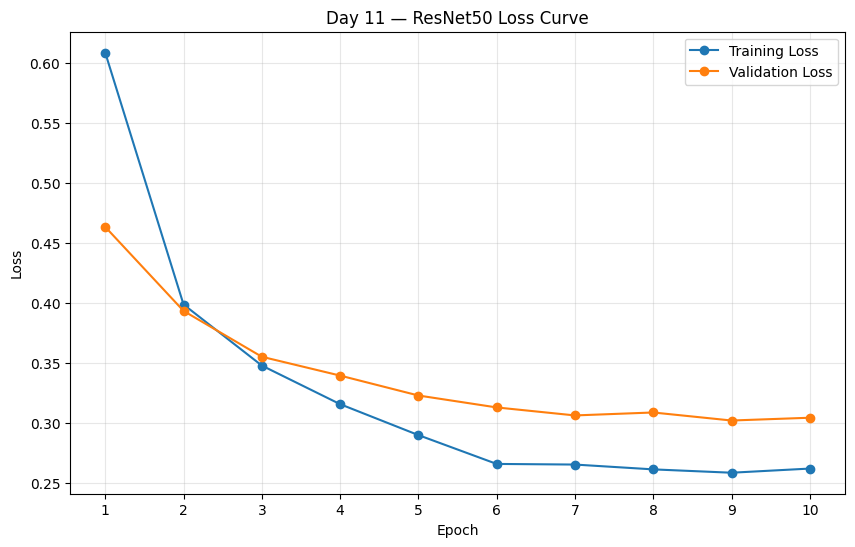

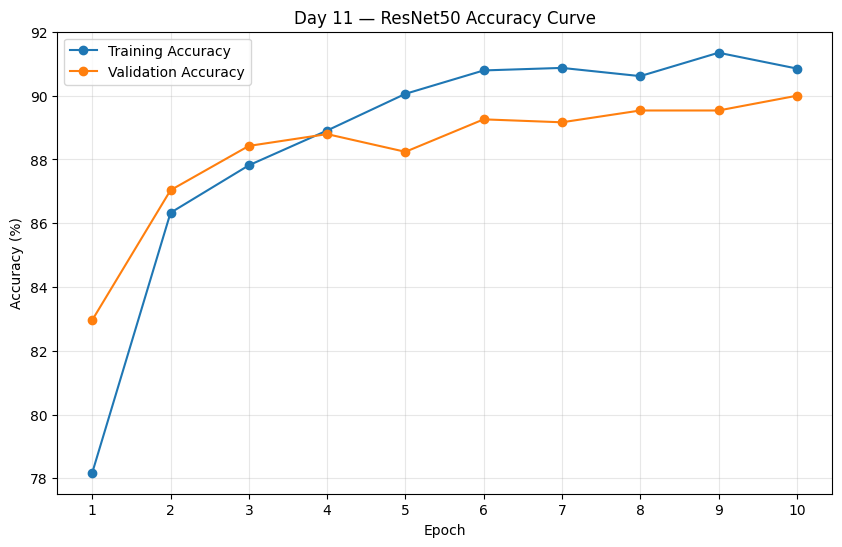


BEST MODEL CHECKPOINT VERIFICATION
Model path exists : True
Architecture      : ResNet50
Classes           : ['glioma', 'meningioma', 'notumor', 'pituitary']
Input size        : 224
Dropout           : 0.1
Learning rate     : 0.002
Batch size        : 32
Best epoch        : 10
Best val accuracy : 90.00%
Best val loss     : 0.3042

Saved figures:
/content/drive/MyDrive/MediScan/figures/day11_resnet50_loss_curve.png
/content/drive/MyDrive/MediScan/figures/day11_resnet50_accuracy_curve.png

✓ DAY 11 RESNET50 VERIFICATION COMPLETE


In [6]:
# ============================================================
# DAY 11 — CELL 6
# RESNET50 TRAINING CURVES + BEST MODEL VERIFICATION
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
DRIVE_REPORTS = DRIVE_PROJECT / "reports"
DRIVE_FIGURES = DRIVE_PROJECT / "figures"
DRIVE_MODELS = DRIVE_PROJECT / "models"

HISTORY_PATH = DRIVE_REPORTS / "day11_resnet50_training_history.csv"
MODEL_PATH = DRIVE_MODELS / "resnet50_best_day11.pth"

# ------------------------------------------------------------
# Load training history
# ------------------------------------------------------------

history_df = pd.read_csv(HISTORY_PATH)

print("=" * 70)
print("RESNET50 TRAINING HISTORY")
print("=" * 70)

print(history_df.to_string(index=False))

# ------------------------------------------------------------
# Best epoch
# ------------------------------------------------------------

best_idx = history_df["val_accuracy"].idxmax()

best_epoch = int(history_df.loc[best_idx, "epoch"])
best_val_accuracy = float(history_df.loc[best_idx, "val_accuracy"])
best_val_loss = float(history_df.loc[best_idx, "val_loss"])

print()
print("=" * 70)
print("BEST RESNET50 RESULT")
print("=" * 70)

print(f"Best epoch        : {best_epoch}")
print(f"Best val accuracy : {best_val_accuracy * 100:.2f}%")
print(f"Best val loss     : {best_val_loss:.4f}")

# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Day 11 — ResNet50 Loss Curve")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True, alpha=0.3)

loss_path = DRIVE_FIGURES / "day11_resnet50_loss_curve.png"

plt.savefig(
    loss_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Accuracy curve
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"] * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"] * 100,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Day 11 — ResNet50 Accuracy Curve")
plt.xticks(history_df["epoch"])
plt.legend()
plt.grid(True, alpha=0.3)

accuracy_path = DRIVE_FIGURES / "day11_resnet50_accuracy_curve.png"

plt.savefig(
    accuracy_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Verify saved checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

print()
print("=" * 70)
print("BEST MODEL CHECKPOINT VERIFICATION")
print("=" * 70)

print("Model path exists :", MODEL_PATH.exists())
print("Architecture      :", checkpoint["architecture"])
print("Classes           :", checkpoint["class_names"])
print("Input size        :", checkpoint["input_size"])
print("Dropout           :", checkpoint["dropout"])
print("Learning rate     :", checkpoint["learning_rate"])
print("Batch size        :", checkpoint["batch_size"])
print("Best epoch        :", checkpoint["best_epoch"])
print(
    "Best val accuracy :",
    f'{checkpoint["best_val_accuracy"] * 100:.2f}%'
)
print(
    "Best val loss     :",
    f'{checkpoint["best_val_loss"]:.4f}'
)

print()
print("Saved figures:")
print(loss_path)
print(accuracy_path)

print()
print("✓ DAY 11 RESNET50 VERIFICATION COMPLETE")

In [7]:
# ============================================================
# DAY 11 — CELL 7
# EFFICIENTNET-B0 vs RESNET50
# VALIDATION PERFORMANCE COMPARISON
# ============================================================

from pathlib import Path
import pandas as pd
import json

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
DRIVE_REPORTS = DRIVE_PROJECT / "reports"

DRIVE_REPORTS.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# EfficientNet-B0 results from Day 8
# ------------------------------------------------------------

EFFICIENTNET_B0_VAL_ACC = 0.9009

# Day 8 best validation loss
EFFICIENTNET_B0_VAL_LOSS = 0.2833

EFFICIENTNET_B0_BEST_EPOCH = 9

# ------------------------------------------------------------
# ResNet50 results from Day 11
# ------------------------------------------------------------

RESNET50_VAL_ACC = 0.9000
RESNET50_VAL_LOSS = 0.3042
RESNET50_BEST_EPOCH = 10

# ------------------------------------------------------------
# Model comparison dataframe
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Architecture": [
        "EfficientNet-B0",
        "ResNet50"
    ],
    "Best_Val_Accuracy": [
        EFFICIENTNET_B0_VAL_ACC,
        RESNET50_VAL_ACC
    ],
    "Best_Val_Loss": [
        EFFICIENTNET_B0_VAL_LOSS,
        RESNET50_VAL_LOSS
    ],
    "Best_Epoch": [
        EFFICIENTNET_B0_BEST_EPOCH,
        RESNET50_BEST_EPOCH
    ]
})

# Convert accuracy to percentage for display
comparison["Val_Accuracy_Percent"] = (
    comparison["Best_Val_Accuracy"] * 100
)

# ------------------------------------------------------------
# Determine winner
# ------------------------------------------------------------

best_accuracy_idx = comparison["Best_Val_Accuracy"].idxmax()

best_model = comparison.loc[
    best_accuracy_idx,
    "Architecture"
]

accuracy_difference = (
    comparison.loc[0, "Best_Val_Accuracy"]
    - comparison.loc[1, "Best_Val_Accuracy"]
) * 100

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("DAY 11 — ARCHITECTURE COMPARISON")
print("=" * 70)

print()

print(
    comparison[
        [
            "Architecture",
            "Best_Val_Accuracy",
            "Val_Accuracy_Percent",
            "Best_Val_Loss",
            "Best_Epoch"
        ]
    ].to_string(index=False)
)

print()
print("=" * 70)
print("COMPARISON SUMMARY")
print("=" * 70)

print(
    f"Best validation model : {best_model}"
)

print(
    f"EfficientNet-B0       : "
    f"{EFFICIENTNET_B0_VAL_ACC * 100:.2f}%"
)

print(
    f"ResNet50              : "
    f"{RESNET50_VAL_ACC * 100:.2f}%"
)

print(
    f"Accuracy difference   : "
    f"{abs(accuracy_difference):.2f} percentage points"
)

print(
    f"EfficientNet-B0 loss  : "
    f"{EFFICIENTNET_B0_VAL_LOSS:.4f}"
)

print(
    f"ResNet50 loss         : "
    f"{RESNET50_VAL_LOSS:.4f}"
)

# ------------------------------------------------------------
# Save comparison CSV
# ------------------------------------------------------------

comparison_csv_path = (
    DRIVE_REPORTS /
    "day11_architecture_comparison.csv"
)

comparison.to_csv(
    comparison_csv_path,
    index=False
)

# ------------------------------------------------------------
# Save comparison JSON
# ------------------------------------------------------------

comparison_json = {
    "models": {
        "EfficientNet-B0": {
            "best_val_accuracy": EFFICIENTNET_B0_VAL_ACC,
            "best_val_loss": EFFICIENTNET_B0_VAL_LOSS,
            "best_epoch": EFFICIENTNET_B0_BEST_EPOCH
        },
        "ResNet50": {
            "best_val_accuracy": RESNET50_VAL_ACC,
            "best_val_loss": RESNET50_VAL_LOSS,
            "best_epoch": RESNET50_BEST_EPOCH
        }
    },
    "best_validation_model": best_model,
    "accuracy_difference_percentage_points": abs(
        accuracy_difference
    )
}

comparison_json_path = (
    DRIVE_REPORTS /
    "day11_architecture_comparison.json"
)

with open(comparison_json_path, "w") as f:
    json.dump(
        comparison_json,
        f,
        indent=2
    )

print()
print("Saved comparison:")
print(comparison_csv_path)
print(comparison_json_path)

print()
print("✓ ARCHITECTURE COMPARISON COMPLETE")

DAY 11 — ARCHITECTURE COMPARISON

   Architecture  Best_Val_Accuracy  Val_Accuracy_Percent  Best_Val_Loss  Best_Epoch
EfficientNet-B0             0.9009                 90.09         0.2833           9
       ResNet50             0.9000                 90.00         0.3042          10

COMPARISON SUMMARY
Best validation model : EfficientNet-B0
EfficientNet-B0       : 90.09%
ResNet50              : 90.00%
Accuracy difference   : 0.09 percentage points
EfficientNet-B0 loss  : 0.2833
ResNet50 loss         : 0.3042

Saved comparison:
/content/drive/MyDrive/MediScan/reports/day11_architecture_comparison.csv
/content/drive/MyDrive/MediScan/reports/day11_architecture_comparison.json

✓ ARCHITECTURE COMPARISON COMPLETE


In [8]:
# ============================================================
# DAY 11 — CELL 8
# PREPARE + VERIFY UNTOUCHED TEST SET
# ============================================================

from pathlib import Path
import json
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")

LOCAL_PROJECT = Path("/content/MediScan")
LOCAL_RAW = LOCAL_PROJECT / "data" / "raw"
LOCAL_PROCESSED = LOCAL_PROJECT / "data" / "processed"

TEST_CSV = LOCAL_PROCESSED / "test.csv"
CLASS_MAP_PATH = LOCAL_PROCESSED / "class_to_idx.json"

# ------------------------------------------------------------
# Restore local files if required
# ------------------------------------------------------------

if not TEST_CSV.exists():
    import shutil

    DRIVE_PROCESSED = DRIVE_PROJECT / "data" / "processed"

    LOCAL_PROCESSED.mkdir(
        parents=True,
        exist_ok=True
    )

    for filename in [
        "test.csv",
        "class_to_idx.json"
    ]:
        src = DRIVE_PROCESSED / filename
        dst = LOCAL_PROCESSED / filename

        if src.exists():
            shutil.copy2(src, dst)

# ------------------------------------------------------------
# Class mapping
# ------------------------------------------------------------

with open(CLASS_MAP_PATH, "r") as f:
    class_to_idx = json.load(f)

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("=" * 70)
print("TEST SET PREPARATION")
print("=" * 70)

print("Class mapping:", class_to_idx)

# ------------------------------------------------------------
# Test CSV
# ------------------------------------------------------------

test_df = pd.read_csv(TEST_CSV)

print()
print("Test samples:", len(test_df))
print()
print("Test distribution:")
print(test_df["label"].value_counts())

# ------------------------------------------------------------
# Test transform
# ------------------------------------------------------------

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class BrainMRIDataset(Dataset):

    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        filename = Path(row["image_path"]).name

        matches = list(
            self.root_dir.rglob(filename)
        )

        if len(matches) == 0:
            raise FileNotFoundError(
                f"Image not found: {filename}"
            )

        image_path = matches[0]

        image = Image.open(
            image_path
        ).convert("RGB")

        label = class_to_idx[row["label"]]

        if self.transform:
            image = self.transform(image)

        return image, label

# ------------------------------------------------------------
# Create test dataset
# ------------------------------------------------------------

test_dataset = BrainMRIDataset(
    test_df,
    LOCAL_RAW,
    transform=test_transform
)

# ------------------------------------------------------------
# Test DataLoader
# ------------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

images, labels = next(iter(test_loader))

print()
print("=" * 70)
print("TEST DATALOADER VERIFICATION")
print("=" * 70)

print("Test dataset size :", len(test_dataset))
print("Number of batches :", len(test_loader))
print("Batch size        :", images.shape[0])
print("Images shape      :", images.shape)
print("Labels shape      :", labels.shape)
print("Images dtype      :", images.dtype)
print("Labels dtype      :", labels.dtype)
print("Labels            :", sorted(labels.unique().tolist()))

print()
print("Shuffle           : False")
print("Augmentation      : None")
print("Normalization     : ImageNet")
print("Purpose           : Final untouched test evaluation")

print()
print("✓ TEST SET READY FOR FINAL MODEL COMPARISON")

TEST SET PREPARATION
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Test samples: 1080

Test distribution:
label
meningioma    270
notumor       270
glioma        270
pituitary     270
Name: count, dtype: int64

TEST DATALOADER VERIFICATION
Test dataset size : 1080
Number of batches : 34
Batch size        : 32
Images shape      : torch.Size([32, 3, 224, 224])
Labels shape      : torch.Size([32])
Images dtype      : torch.float32
Labels dtype      : torch.int64
Labels            : [0, 1, 2, 3]

Shuffle           : False
Augmentation      : None
Normalization     : ImageNet
Purpose           : Final untouched test evaluation

✓ TEST SET READY FOR FINAL MODEL COMPARISON


In [9]:
# ============================================================
# DAY 11 — CELL 9
# FINAL TEST EVALUATION
# EFFICIENTNET-B0 vs RESNET50
# ============================================================

from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import torch
from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
DRIVE_MODELS = DRIVE_PROJECT / "models"
DRIVE_REPORTS = DRIVE_PROJECT / "reports"

EFFICIENTNET_PATH = (
    DRIVE_MODELS / "efficientnet_b0_best_day8.pth"
)

RESNET50_PATH = (
    DRIVE_MODELS / "resnet50_best_day11.pth"
)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# ------------------------------------------------------------
# Class information
# ------------------------------------------------------------

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

NUM_CLASSES = len(class_names)

# ------------------------------------------------------------
# Helper: load EfficientNet-B0
# ------------------------------------------------------------

def load_efficientnet():

    checkpoint = torch.load(
        EFFICIENTNET_PATH,
        map_location=device,
        weights_only=False
    )

    model = models.efficientnet_b0(
        weights=None
    )

    model.classifier = torch.nn.Sequential(
        torch.nn.Dropout(
            p=checkpoint["dropout"]
        ),
        torch.nn.Linear(
            1280,
            NUM_CLASSES
        )
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model = model.to(device)
    model.eval()

    return model

# ------------------------------------------------------------
# Helper: load ResNet50
# ------------------------------------------------------------

def load_resnet50():

    checkpoint = torch.load(
        RESNET50_PATH,
        map_location=device,
        weights_only=False
    )

    model = models.resnet50(
        weights=None
    )

    model.fc = torch.nn.Sequential(
        torch.nn.Dropout(
            p=checkpoint["dropout"]
        ),
        torch.nn.Linear(
            2048,
            NUM_CLASSES
        )
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model = model.to(device)
    model.eval()

    return model

# ------------------------------------------------------------
# Helper: evaluate model
# ------------------------------------------------------------

def evaluate_model(model, model_name):

    y_true = []
    y_pred = []

    start_time = time.time()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

    evaluation_time = time.time() - start_time

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "Evaluation_Time_Seconds": evaluation_time,
        "Samples": len(y_true)
    }, y_true, y_pred

# ------------------------------------------------------------
# Load models
# ------------------------------------------------------------

print("=" * 70)
print("LOADING MODELS")
print("=" * 70)

efficientnet = load_efficientnet()

print("✓ EfficientNet-B0 loaded")

resnet50 = load_resnet50()

print("✓ ResNet50 loaded")

# ------------------------------------------------------------
# Evaluate EfficientNet-B0
# ------------------------------------------------------------

print()
print("=" * 70)
print("EVALUATING EFFICIENTNET-B0")
print("=" * 70)

eff_results, eff_true, eff_pred = evaluate_model(
    efficientnet,
    "EfficientNet-B0"
)

print(
    f"Accuracy  : {eff_results['Accuracy'] * 100:.2f}%"
)

print(
    f"Precision : {eff_results['Precision']:.4f}"
)

print(
    f"Recall    : {eff_results['Recall']:.4f}"
)

print(
    f"F1 Score  : {eff_results['F1_Score']:.4f}"
)

# ------------------------------------------------------------
# Evaluate ResNet50
# ------------------------------------------------------------

print()
print("=" * 70)
print("EVALUATING RESNET50")
print("=" * 70)

res_results, res_true, res_pred = evaluate_model(
    resnet50,
    "ResNet50"
)

print(
    f"Accuracy  : {res_results['Accuracy'] * 100:.2f}%"
)

print(
    f"Precision : {res_results['Precision']:.4f}"
)

print(
    f"Recall    : {res_results['Recall']:.4f}"
)

print(
    f"F1 Score  : {res_results['F1_Score']:.4f}"
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

comparison_df = pd.DataFrame([
    eff_results,
    res_results
])

print()
print("=" * 70)
print("FINAL TEST SET COMPARISON")
print("=" * 70)

display(
    comparison_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "Evaluation_Time_Seconds"
        ]
    ]
)

# ------------------------------------------------------------
# Determine winner by accuracy
# ------------------------------------------------------------

winner_idx = comparison_df["Accuracy"].idxmax()

winner = comparison_df.loc[
    winner_idx,
    "Model"
]

accuracy_difference = (
    abs(
        comparison_df.loc[0, "Accuracy"]
        -
        comparison_df.loc[1, "Accuracy"]
    )
    * 100
)

print()
print("=" * 70)
print("FINAL RESULT")
print("=" * 70)

print("Best test model :", winner)

print(
    f"Accuracy difference : "
    f"{accuracy_difference:.2f} percentage points"
)

# ------------------------------------------------------------
# Save comparison
# ------------------------------------------------------------

comparison_csv = (
    DRIVE_REPORTS /
    "day11_final_test_comparison.csv"
)

comparison_df.to_csv(
    comparison_csv,
    index=False
)

# ------------------------------------------------------------
# Save predictions
# ------------------------------------------------------------

np.save(
    DRIVE_REPORTS / "day11_efficientnet_y_true.npy",
    eff_true
)

np.save(
    DRIVE_REPORTS / "day11_efficientnet_y_pred.npy",
    eff_pred
)

np.save(
    DRIVE_REPORTS / "day11_resnet50_y_true.npy",
    res_true
)

np.save(
    DRIVE_REPORTS / "day11_resnet50_y_pred.npy",
    res_pred
)

print()
print("Comparison saved:")
print(comparison_csv)

print()
print("✓ DAY 11 FINAL TEST EVALUATION COMPLETE")

LOADING MODELS
✓ EfficientNet-B0 loaded
✓ ResNet50 loaded

EVALUATING EFFICIENTNET-B0
Accuracy  : 91.20%
Precision : 0.9132
Recall    : 0.9120
F1 Score  : 0.9116

EVALUATING RESNET50
Accuracy  : 90.93%
Precision : 0.9094
Recall    : 0.9093
F1 Score  : 0.9083

FINAL TEST SET COMPARISON


,Model,Accuracy,Precision,Recall,F1_Score,Evaluation_Time_Seconds
0,EfficientNet-B0,0.912037,0.913186,0.912037,0.911563,15.577589
1,ResNet50,0.909259,0.909447,0.909259,0.908310,12.144487



FINAL RESULT
Best test model : EfficientNet-B0
Accuracy difference : 0.28 percentage points

Comparison saved:
/content/drive/MyDrive/MediScan/reports/day11_final_test_comparison.csv

✓ DAY 11 FINAL TEST EVALUATION COMPLETE


DAY 11 — PER-CLASS METRICS COMPARISON


,Class,EfficientNet_Precision,EfficientNet_Recall,EfficientNet_F1,ResNet50_Precision,ResNet50_Recall,ResNet50_F1
0,glioma,0.9458,0.8407,0.8902,0.9380,0.8407,0.8867
1,meningioma,0.8423,0.8704,0.8561,0.8502,0.8407,0.8454
2,notumor,0.9301,0.9852,0.9568,0.9437,0.9926,0.9675
3,pituitary,0.9345,0.9519,0.9431,0.9059,0.9630,0.9336



EfficientNet-B0 Confusion Matrix:
[[227  33   8   2]
 [ 13 235   7  15]
 [  0   3 266   1]
 [  0   8   5 257]]

ResNet50 Confusion Matrix:
[[227  34   7   2]
 [ 14 227   5  24]
 [  0   1 268   1]
 [  1   5   4 260]]


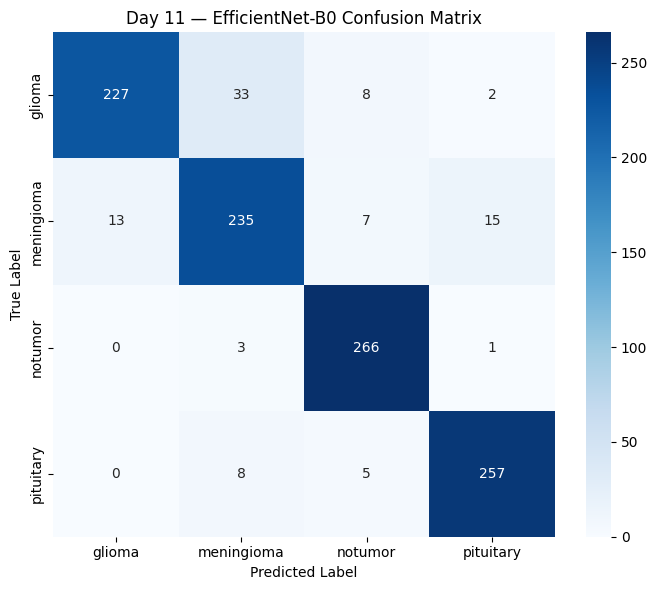

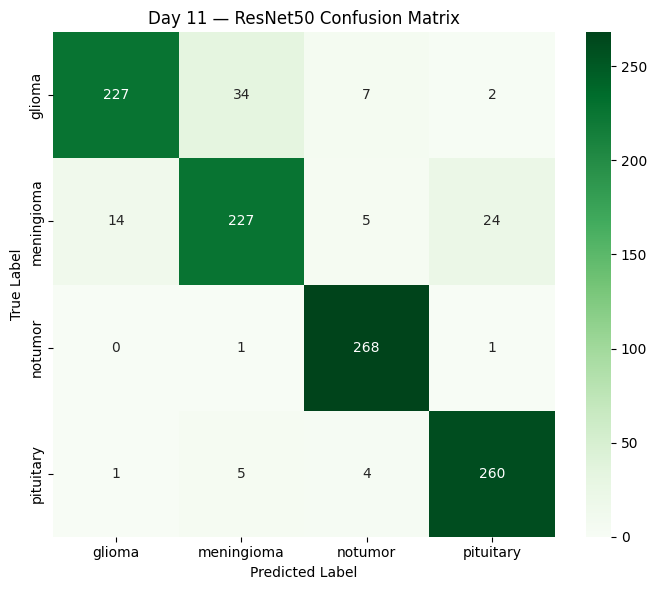


Saved per-class comparison:
/content/drive/MyDrive/MediScan/reports/day11_per_class_comparison.csv

Saved confusion matrices:
/content/drive/MyDrive/MediScan/figures/day11_efficientnet_confusion_matrix.png
/content/drive/MyDrive/MediScan/figures/day11_resnet50_confusion_matrix.png

✓ DAY 11 PER-CLASS COMPARISON COMPLETE


In [10]:
# ============================================================
# DAY 11 — CELL 10
# PER-CLASS METRICS + CONFUSION MATRICES
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DRIVE_PROJECT = Path("/content/drive/MyDrive/MediScan")
DRIVE_REPORTS = DRIVE_PROJECT / "reports"
DRIVE_FIGURES = DRIVE_PROJECT / "figures"

DRIVE_REPORTS.mkdir(parents=True, exist_ok=True)
DRIVE_FIGURES.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Class names
# ------------------------------------------------------------

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

# ------------------------------------------------------------
# Load saved predictions
# ------------------------------------------------------------

eff_true = np.load(
    DRIVE_REPORTS / "day11_efficientnet_y_true.npy"
)

eff_pred = np.load(
    DRIVE_REPORTS / "day11_efficientnet_y_pred.npy"
)

res_true = np.load(
    DRIVE_REPORTS / "day11_resnet50_y_true.npy"
)

res_pred = np.load(
    DRIVE_REPORTS / "day11_resnet50_y_pred.npy"
)

# ------------------------------------------------------------
# Per-class classification reports
# ------------------------------------------------------------

eff_report = classification_report(
    eff_true,
    eff_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

res_report = classification_report(
    res_true,
    res_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# ------------------------------------------------------------
# Create comparison dataframe
# ------------------------------------------------------------

rows = []

for class_name in class_names:

    rows.append({
        "Class": class_name,
        "EfficientNet_Precision": eff_report[class_name]["precision"],
        "EfficientNet_Recall": eff_report[class_name]["recall"],
        "EfficientNet_F1": eff_report[class_name]["f1-score"],
        "ResNet50_Precision": res_report[class_name]["precision"],
        "ResNet50_Recall": res_report[class_name]["recall"],
        "ResNet50_F1": res_report[class_name]["f1-score"]
    })

per_class_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("DAY 11 — PER-CLASS METRICS COMPARISON")
print("=" * 70)

display(
    per_class_df.style.format({
        "EfficientNet_Precision": "{:.4f}",
        "EfficientNet_Recall": "{:.4f}",
        "EfficientNet_F1": "{:.4f}",
        "ResNet50_Precision": "{:.4f}",
        "ResNet50_Recall": "{:.4f}",
        "ResNet50_F1": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

eff_cm = confusion_matrix(
    eff_true,
    eff_pred
)

res_cm = confusion_matrix(
    res_true,
    res_pred
)

print()
print("EfficientNet-B0 Confusion Matrix:")
print(eff_cm)

print()
print("ResNet50 Confusion Matrix:")
print(res_cm)

# ------------------------------------------------------------
# Plot EfficientNet confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    eff_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Day 11 — EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

eff_cm_path = DRIVE_FIGURES / "day11_efficientnet_confusion_matrix.png"

plt.savefig(
    eff_cm_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Plot ResNet50 confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

sns.heatmap(
    res_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Day 11 — ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

res_cm_path = DRIVE_FIGURES / "day11_resnet50_confusion_matrix.png"

plt.savefig(
    res_cm_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Save per-class comparison
# ------------------------------------------------------------

per_class_csv = DRIVE_REPORTS / "day11_per_class_comparison.csv"

per_class_df.to_csv(
    per_class_csv,
    index=False
)

print()
print("Saved per-class comparison:")
print(per_class_csv)

print()
print("Saved confusion matrices:")
print(eff_cm_path)
print(res_cm_path)

print()
print("✓ DAY 11 PER-CLASS COMPARISON COMPLETE")